## 1) Bootstrap and Utility Toolkit

In [4]:
import os
import sys
import subprocess

def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("opencv-python", "cv2")
ensure_package("numpy")
ensure_package("matplotlib")

import cv2
import numpy as np
import matplotlib.pyplot as plt

def banner(step_title):
    normalized_title = str(step_title).strip() or "OpenCV Step"
    print(f"\n{'=' * 16} {normalized_title} {'=' * 16}")

def assert_bgr_uint8(image_value, label="image"):
    if not isinstance(image_value, np.ndarray):
        raise TypeError(f"{label} must be a NumPy array.")
    if image_value.ndim != 3 or image_value.shape[2] != 3:
        raise ValueError(f"{label} must have shape (height, width, 3).")
    if image_value.dtype != np.uint8:
        raise ValueError(f"{label} must use dtype uint8.")

def render_tiles(tile_items, headline, columns=3):
    if not tile_items:
        raise ValueError("image_items cannot be empty.")
    if columns <= 0:
        raise ValueError("cols must be greater than 0.")

    row_count = int(np.ceil(len(tile_items) / columns))
    _, axes_grid = plt.subplots(row_count, columns, figsize=(5 * columns, 4 * row_count))
    axes_grid = np.array(axes_grid).reshape(row_count, columns)

    for axis in axes_grid.ravel():
        axis.axis("off")

    for idx, (caption, image_data, mode) in enumerate(tile_items):
        r_idx, c_idx = divmod(idx, columns)
        panel = axes_grid[r_idx, c_idx]
        if mode == "gray":
            panel.imshow(image_data, cmap="gray")
        else:
            panel.imshow(image_data)
        panel.set_title(caption)
        panel.axis("off")

    plt.suptitle(headline, fontsize=13)
    plt.tight_layout()
    plt.show()

def make_demo_canvas(width=420, height=300):
    if not isinstance(width, int) or not isinstance(height, int):
        raise TypeError("width and height must be integers.")
    if width < 120 or height < 120:
        raise ValueError("width and height should each be at least 120.")

    board = np.zeros((height, width, 3), dtype=np.uint8)
    board[:] = (18, 18, 28)

    for stripe in range(0, width, 24):
        stripe_color = (30 + (stripe % 60), 70 + (stripe % 100), 120 + (stripe % 80))
        cv2.line(board, (stripe, 0), (stripe, height), stripe_color, 2)

    triangle = np.array([[45, 250], [200, 55], [355, 245]], dtype=np.int32)
    cv2.fillPoly(board, [triangle], (50, 180, 235))
    cv2.circle(board, (90, 70), 26, (245, 210, 70), -1)
    cv2.circle(board, (330, 95), 34, (70, 230, 160), -1)
    cv2.rectangle(board, (160, 180), (260, 270), (230, 90, 140), -1)
    cv2.putText(board, "OpenCV Demo", (105, 293), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (240, 240, 240), 2)
    return board

source_bgr = make_demo_canvas()
assert_bgr_uint8(source_bgr, "base_image")
banner("Environment Ready")
print(f"Image shape: {source_bgr.shape} | dtype: {source_bgr.dtype}")

Installing missing package: opencv-python
Installing missing package: matplotlib

================ Environment Ready ================
Image shape: (300, 420, 3) | dtype: uint8


## 2) Store, Reload, and Visualize Image


================ Read/Write/Display ================


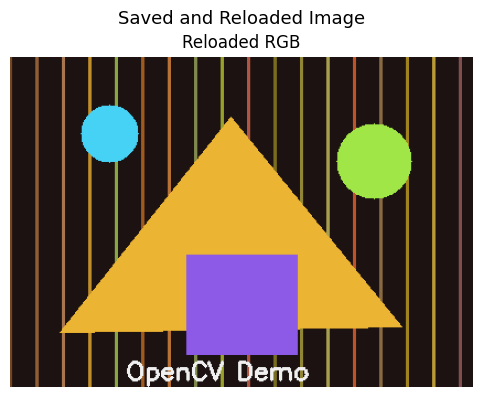

Status: image saved and loaded successfully.


In [5]:
def persist_then_load(input_bgr, output_path="opencv_source.png"):
    assert_bgr_uint8(input_bgr, "image_data")
    if not isinstance(output_path, str) or not output_path.strip():
        raise ValueError("output_path must be a non-empty string.")

    ok = cv2.imwrite(output_path, input_bgr)
    if not ok:
        raise RuntimeError(f"Could not save image to {output_path}")

    loaded = cv2.imread(output_path)
    if loaded is None:
        raise RuntimeError(f"Image was saved but could not be loaded: {output_path}")
    return loaded

banner("Read/Write/Display")
saved_bgr = persist_then_load(source_bgr, "opencv_source.png")
saved_rgb = cv2.cvtColor(saved_bgr, cv2.COLOR_BGR2RGB)

render_tiles(
    [("Reloaded RGB", saved_rgb, "rgb")],
    headline="Saved and Reloaded Image",
    columns=1,
)
print("Status: image saved and loaded successfully.")

## 3) Scale and Middle Crop


================ Resize and Crop ================


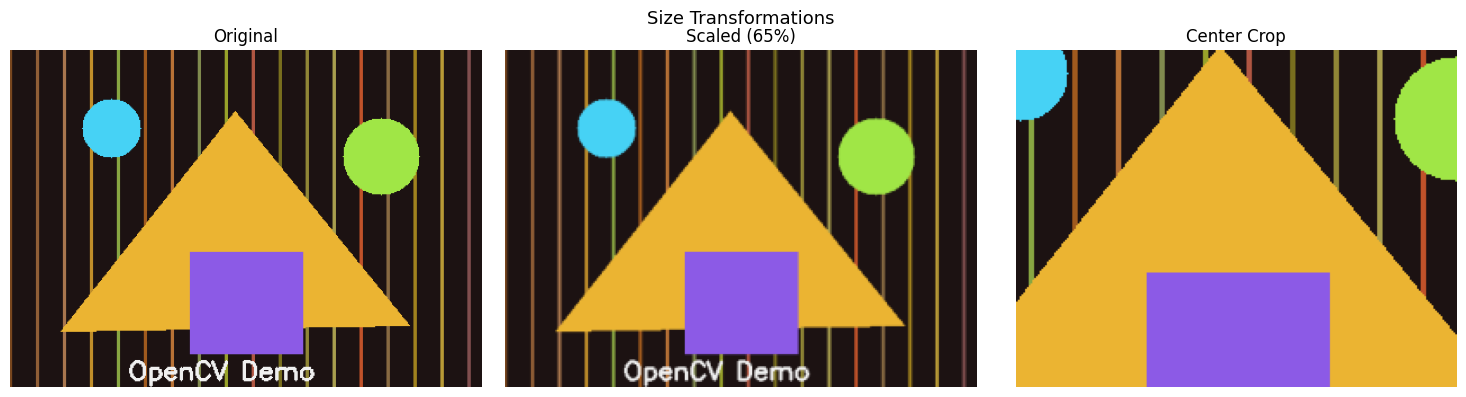

In [6]:
def resize_percent(input_bgr, percent=70):
    assert_bgr_uint8(input_bgr, "image_data")
    if not (10 <= percent <= 300):
        raise ValueError("scale_percent must be between 10 and 300.")

    ratio = percent / 100.0
    target_w = max(1, int(input_bgr.shape[1] * ratio))
    target_h = max(1, int(input_bgr.shape[0] * ratio))
    return cv2.resize(input_bgr, (target_w, target_h), interpolation=cv2.INTER_AREA)

def crop_center_percent(input_bgr, width_pct=55, height_pct=55):
    assert_bgr_uint8(input_bgr, "image_data")
    if not (10 <= width_pct <= 100 and 10 <= height_pct <= 100):
        raise ValueError("Crop percentages must be between 10 and 100.")

    img_h, img_w = input_bgr.shape[:2]
    cut_w = int(img_w * width_pct / 100)
    cut_h = int(img_h * height_pct / 100)

    left = (img_w - cut_w) // 2
    top = (img_h - cut_h) // 2
    right = left + cut_w
    bottom = top + cut_h
    return input_bgr[top:bottom, left:right]

banner("Resize and Crop")
shrunk_bgr = resize_percent(saved_bgr, 65)
focus_bgr = crop_center_percent(saved_bgr, 58, 62)

render_tiles(
    [
        ("Original", cv2.cvtColor(saved_bgr, cv2.COLOR_BGR2RGB), "rgb"),
        ("Scaled (65%)", cv2.cvtColor(shrunk_bgr, cv2.COLOR_BGR2RGB), "rgb"),
        ("Center Crop", cv2.cvtColor(focus_bgr, cv2.COLOR_BGR2RGB), "rgb"),
    ],
    headline="Size Transformations",
    columns=3,
)

## 4) Transforming Color Representations

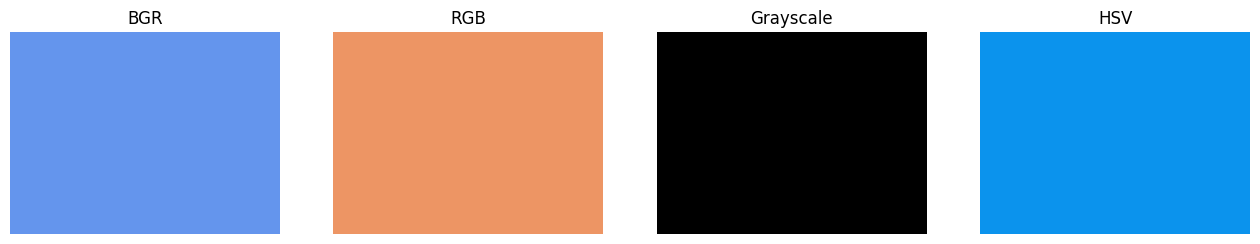

In [ ]:
def create_color_views(input_bgr):
    assert_bgr_uint8(input_bgr, "image_data")
    rgb_view = cv2.cvtColor(input_bgr, cv2.COLOR_BGR2RGB)
    gray_view = cv2.cvtColor(input_bgr, cv2.COLOR_BGR2GRAY)
    hsv_native = cv2.cvtColor(input_bgr, cv2.COLOR_BGR2HSV)
    hsv_view = cv2.cvtColor(hsv_native, cv2.COLOR_HSV2RGB)
    return rgb_view, gray_view, hsv_view

banner("Color Spaces")
rgb_view, gray_view, hsv_view = create_color_views(saved_bgr)

render_tiles(
    [
        ("RGB", rgb_view, "rgb"),
        ("Grayscale", gray_view, "gray"),
        ("HSV (Preview)", hsv_view, "rgb"),
    ],
    headline="Color Conversion Results",
    columns=3,
)
print(f"Channels in RGB image: {rgb_view.shape[2]}")

## 5) Primitive Drawing Operations

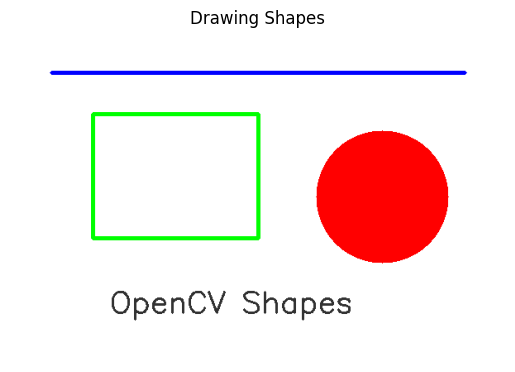

In [ ]:
def build_drawing_board(image_size=(420, 600)):
    if not isinstance(image_size, tuple) or len(image_size) != 2:
        raise ValueError("image_size must be a tuple like (height, width).")
    frame_h, frame_w = image_size
    if frame_h < 200 or frame_w < 200:
        raise ValueError("Both image dimensions must be at least 200.")

    board = np.full((frame_h, frame_w, 3), 252, dtype=np.uint8)
    cv2.rectangle(board, (14, 14), (frame_w - 14, frame_h - 14), (80, 80, 80), 2)

    poly = np.array([[70, 300], [140, 150], [240, 330], [310, 170], [390, 315]], dtype=np.int32)
    cv2.polylines(board, [poly], False, (230, 70, 70), 5)
    cv2.circle(board, (485, 110), 65, (70, 140, 230), -1)
    cv2.ellipse(board, (470, 285), (85, 42), -20, 0, 330, (85, 200, 110), -1)
    cv2.putText(board, "Shapes + Text", (65, 380), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (40, 40, 40), 2)
    return board

banner("Drawing")
drawing_bgr = build_drawing_board()
render_tiles(
    [("Drawn Scene", cv2.cvtColor(drawing_bgr, cv2.COLOR_BGR2RGB), "rgb")],
    headline="OpenCV Drawing Functions",
    columns=1,
)

## 6) Percentile Threshold plus Auto Canny

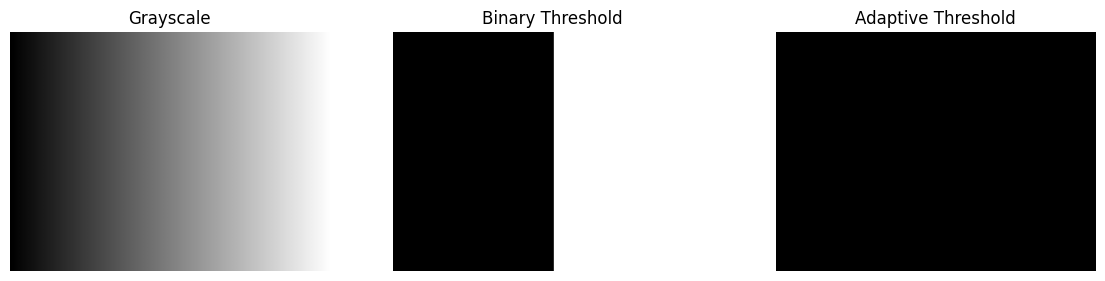

In [ ]:
def threshold_by_percentile(gray_u8, pct=60):
    if not isinstance(gray_u8, np.ndarray) or gray_u8.ndim != 2:
        raise ValueError("gray_image must be a 2D NumPy array.")
    if gray_u8.dtype != np.uint8:
        raise ValueError("gray_image dtype must be uint8.")
    if not (1 <= pct <= 99):
        raise ValueError("percentile_value must be between 1 and 99.")

    cutoff = int(np.percentile(gray_u8, pct))
    _, binary_u8 = cv2.threshold(gray_u8, cutoff, 255, cv2.THRESH_BINARY)
    return cutoff, binary_u8

def canny_auto(gray_u8):
    if not isinstance(gray_u8, np.ndarray) or gray_u8.ndim != 2:
        raise ValueError("gray_image must be a 2D NumPy array.")
    middle = int(np.median(gray_u8))
    lo = max(0, int(0.66 * middle))
    hi = min(255, int(1.33 * middle))
    return cv2.Canny(gray_u8, lo, hi)

banner("Threshold + Edges")
gray_edges = cv2.cvtColor(saved_bgr, cv2.COLOR_BGR2GRAY)
picked_threshold, binary_mask = threshold_by_percentile(gray_edges, pct=62)
edge_map = canny_auto(gray_edges)

render_tiles(
    [
        ("Grayscale", gray_edges, "gray"),
        (f"Binary @ {picked_threshold}", binary_mask, "gray"),
        ("Auto Canny", edge_map, "gray"),
    ],
    headline="Thresholding and Edge Detection",
    columns=3,
)

## 7) External Contours with Metrics

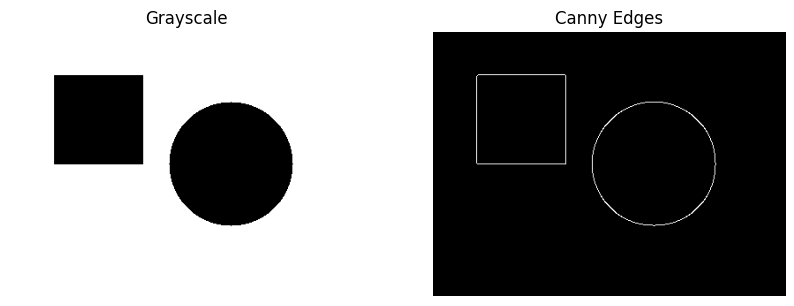

In [ ]:
def collect_contour_metrics(binary_u8):
    if not isinstance(binary_u8, np.ndarray) or binary_u8.ndim != 2:
        raise ValueError("binary_image must be a 2D NumPy array.")

    contour_list, _ = cv2.findContours(binary_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rows = []
    for number, contour in enumerate(contour_list, start=1):
        area_value = cv2.contourArea(contour)
        perimeter_value = cv2.arcLength(contour, True)
        rows.append((number, round(area_value, 1), round(perimeter_value, 1)))
    return contour_list, rows

banner("Contour Detection")
contours, contour_rows = collect_contour_metrics(binary_mask)
contour_canvas = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_canvas, contours, -1, (0, 0, 255), 2)

if contour_rows:
    print("ID | Area | Perimeter")
    for number, area_value, perimeter_value in contour_rows:
        print(f"{number:>2} | {area_value:>5} | {perimeter_value:>8}")
else:
    print("No contours found.")

render_tiles(
    [
        ("Binary Input", binary_mask, "gray"),
        ("Contours Overlay", cv2.cvtColor(contour_canvas, cv2.COLOR_BGR2RGB), "rgb"),
    ],
    headline="Contour Results",
    columns=2,
)

## 8) Haar Cascade Face Boxing

In [ ]:
def locate_face_cascade():
    possible_locations = (
        "haarcascade_frontalface_default.xml",
        "haarcascade_frontalface_default (1).xml",
        os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml"),
    )
    matched_path = next((path for path in possible_locations if os.path.exists(path)), None)
    if matched_path is None:
        raise FileNotFoundError("No face cascade XML file was found in local folder or OpenCV data directory.")
    return matched_path

def run_face_detection(frame_bgr, cascade_xml):
    assert_bgr_uint8(frame_bgr, "input_bgr_image")
    if not isinstance(cascade_xml, str) or not cascade_xml.strip():
        raise ValueError("cascade_path must be a non-empty string.")

    model = cv2.CascadeClassifier(cascade_xml)
    if model.empty():
        raise RuntimeError(f"Cascade could not be loaded: {cascade_xml}")

    gray_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    detections = model.detectMultiScale(
        gray_frame,
        scaleFactor=1.12,
        minNeighbors=4,
        minSize=(30, 30),
    )

    boxed = frame_bgr.copy()
    for x_pos, y_pos, box_w, box_h in detections:
        cv2.rectangle(boxed, (x_pos, y_pos), (x_pos + box_w, y_pos + box_h), (0, 255, 0), 2)
    return boxed, detections

def build_face_test_image():
    sample = np.full((280, 280, 3), 235, dtype=np.uint8)
    cv2.circle(sample, (140, 140), 92, (180, 160, 140), -1)
    cv2.circle(sample, (105, 120), 16, (50, 50, 50), -1)
    cv2.circle(sample, (175, 120), 16, (50, 50, 50), -1)
    cv2.ellipse(sample, (140, 170), (36, 20), 0, 10, 170, (40, 40, 90), 3)
    cv2.rectangle(sample, (70, 50), (210, 70), (60, 60, 60), -1)
    return sample

banner("Face Detection")
cascade_file = locate_face_cascade()
face_input_bgr = build_face_test_image()
face_result_image, face_boxes = run_face_detection(face_input_bgr, cascade_file)
print(f"Cascade file: {cascade_file}")
print(f"Faces detected: {len(face_boxes)}")

render_tiles(
    [
        ("Face Test Input", cv2.cvtColor(face_input_bgr, cv2.COLOR_BGR2RGB), "rgb"),
        ("Detection Preview", cv2.cvtColor(face_result_image, cv2.COLOR_BGR2RGB), "rgb"),
    ],
    headline="Cascade Face Detection",
    columns=2,
)

## 9) Consolidated Output View

Faces detected: 1


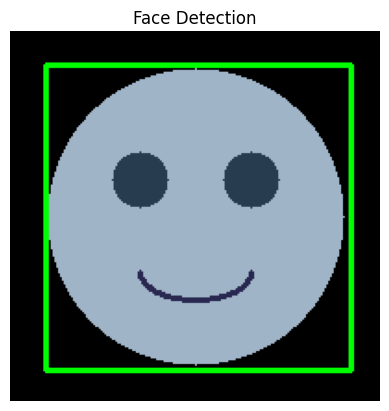

In [ ]:
banner("Final Snapshot")
render_tiles(
    [
        ("Original", cv2.cvtColor(saved_bgr, cv2.COLOR_BGR2RGB), "rgb"),
        ("Edges", edge_map, "gray"),
        ("Contours", cv2.cvtColor(contour_canvas, cv2.COLOR_BGR2RGB), "rgb"),
        ("Face Detection", cv2.cvtColor(face_result_image, cv2.COLOR_BGR2RGB), "rgb"),
    ],
    headline="Main OpenCV Functions - Summary",
    columns=2,
)
print("Notebook status: Completed core OpenCV tasks successfully.")